[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter17_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 17: Bubbles and Crashes

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces every chart and table of Lecture 17: simulated rational bubbles, nine historical run-ups, the Bubbles for Fama analysis of Greenwood, Shleifer and You (2019) on 48 US industries, GSADF/BSADF tests, LPPLS fits and Markov-switching regimes.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_17'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
# On Colab: !pip install xlrd
import io
import json
import os
import re
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import optimize, stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [2]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Course colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'   # reference lines, bands and grid only
Teal     = '#17A2B8'
Magenta  = '#D63384'
Brown    = '#795548'

HERE = '.'
SEED = 42
R_MC = 2000
# Computing the confidence indicator takes several minutes; set RECOMPUTE = True to recompute it, otherwise precomputed values are used.
RECOMPUTE = False
QL_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/Quantlets/Ch_17/'


def save_fig(name):
    """Save the figure as transparent PDF and PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend(fig, axes, ncol=3, y=0.0):
    """One legend for a multi-panel figure, below the figure."""
    h, l = [], []
    for ax in np.atleast_1d(axes):
        for hh, ll in zip(*ax.get_legend_handles_labels()):
            if ll not in l and not ll.startswith('_'):
                h.append(hh)
                l.append(ll)
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple, np.ndarray)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.floating, np.integer, np.bool_)):
        return o.item()
    if isinstance(o, pd.Timestamp):
        return str(o.date())
    return o


def yrs(idx):
    """Date -> decimal years."""
    idx = pd.DatetimeIndex(idx)
    return np.asarray(idx.year + (idx.dayofyear - 1) / 365.25)


def todate(x):
    """Ani zecimali -> data."""
    y = int(np.floor(x))
    return pd.Timestamp(f'{y}-01-01') + pd.Timedelta(days=float((x - y) * 365.25))


def d2s(d):
    return None if d is None else str(pd.Timestamp(d).date())


import shutil
import tempfile
HERE = tempfile.gettempdir()   # intermediate tables are written to a temporary folder
# precomputed LPPLS confidence indicators
for _d in ('.', os.path.join('..', 'Quantlets', 'Ch_17'), os.path.join('..', '..', 'Quantlets', 'Ch_17')):
    for _f in ('ch17_lppls_ci_btc.csv', 'ch17_lppls_ci_ndx.csv'):
        if os.path.exists(os.path.join(_d, _f)) and not os.path.exists(os.path.join(HERE, _f)):
            shutil.copy(os.path.join(_d, _f), HERE)


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

## Data

- Daily closes up to 18 September 2026 (Nasdaq 100, S&P 500, BET, BET-FI, Bitcoin, Ethereum, Dogecoin, NVIDIA, Cisco, Tesla, GameStop, Strategy (formerly MicroStrategy)).
- Weekly and monthly series: last close of the week or month; stocks adjusted for dividends and splits.
- S&P Composite monthly since 1871 (Robert J. Shiller); 49 US industry portfolios (Kenneth French Data Library), of which Greenwood, Shleifer and You (2019, *Bubbles for Fama*) use the first 48.
- The last, incomplete week or month is dated at its last observation (18 September 2026).

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# read the course data
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# name -> (symbol, label, type, price field, start date)
MARKETS = {
    'sp500': ('GSPC.INDX',   'S&P 500',        'index',  'close',          '1990-01-01'),
    'ndx':   ('NDX.INDX',    'Nasdaq 100',     'index',  'close',          '1990-01-01'),
    'bet':   ('BET',         'BET',            'index',  'close',          '1997-09-19'),
    'betfi': ('BETFI.INDX',  'BET-FI',         'index',  'close',          '2012-01-25'),
    'btc':   ('BTC-USD.CC',  'Bitcoin',        'crypto', 'close',          '2014-09-17'),
    'eth':   ('ETH-USD.CC',  'Ethereum',       'crypto', 'close',          '2016-01-01'),
    'doge':  ('DOGE-USD.CC', 'Dogecoin',       'crypto', 'close',          '2017-01-01'),
    'nvda':  ('NVDA.US',     'NVIDIA',         'stock',  'adjusted_close', '1999-01-22'),
    'csco':  ('CSCO.US',     'Cisco Systems',  'stock',  'adjusted_close', '1990-02-16'),
    'tsla':  ('TSLA.US',     'Tesla',          'stock',  'adjusted_close', '2010-06-29'),
    'gme':   ('GME.US',      'GameStop',       'stock',  'adjusted_close', '2002-02-13'),
    'mstr':  ('MSTR.US',     'Strategy (MicroStrategy)', 'stock', 'adjusted_close', '1998-06-11'),
}
LABELS = {k: v[1] for k, v in MARKETS.items()}

SHILLER_URLS = ['https://img1.wsimg.com/blobby/go/e5e77e0b-59d1-44d9-ab25-4763ac982e53/downloads/ie_data.xls',
                'http://www.econ.yale.edu/~shiller/data/ie_data.xls']
FRENCH = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'

_CACHE = {}


def read_market(symbol):
    """Read the daily prices of one asset from the course data."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def price(name, freq='D', start=None, end=END):
    """Price level: 'D' daily (cleaned), 'W' last price of the week, 'M' last price of the month."""
    symbol, _, kind, col, start0 = MARKETS[name]
    s = read_market(symbol)[col].loc[start or start0:end]
    s = s[s > 0].dropna()
    if kind != 'crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
    if kind == 'index':
        s = s[s.diff() != 0]                  # drop holidays filled with the previous price
    last = s.index[-1]
    if freq == 'W':
        s = s.resample('W-FRI').last().dropna()
    elif freq == 'M':
        s = s.resample('ME').last().dropna()
    if freq in ('W', 'M') and s.index[-1] > last:
        s.index = s.index[:-1].append(pd.DatetimeIndex([last]))   # last incomplete period: dated at its last observation
    return s.rename(name)


def shiller_urls():
    """Addresses of Shiller's ie_data.xls: the current shillerdata.com link, then known copies."""
    urls = []
    try:
        html = urllib.request.urlopen(urllib.request.Request('https://shillerdata.com/', headers={'User-Agent': 'Mozilla/5.0'}),
                                      timeout=60).read().decode('utf-8', 'ignore')
        urls += ['https:' + u if u.startswith('//') else u
                 for u in re.findall(r'href="([^"]*ie_data\.xls[^"]*)"', html)]
    except Exception:
        pass
    return urls + SHILLER_URLS


def shiller():
    """Monthly S&P Composite (Shiller): real price, real dividend and the price-dividend ratio (P/D)."""
    if 'shiller' in _CACHE:
        return _CACHE['shiller']
    raw = None
    for url in shiller_urls():
        try:
            raw = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'}),
                                         timeout=120).read()
            break
        except Exception:
            continue
    d = pd.read_excel(io.BytesIO(raw), sheet_name='Data', header=None, skiprows=8)
    d = d.iloc[:, [0, 1, 2, 7, 8]]
    d.columns = ['date', 'P', 'D', 'real_P', 'real_D']
    d = d[pd.to_numeric(d['date'], errors='coerce').notna()].copy()
    yr = d['date'].astype(float)
    year = np.floor(yr + 1e-9).astype(int)
    month = np.round((yr - year) * 100).astype(int)
    d.index = pd.to_datetime(dict(year=year, month=month, day=1)) + pd.offsets.MonthEnd(0)
    d = d[['P', 'D', 'real_P', 'real_D']].apply(pd.to_numeric, errors='coerce').dropna()
    d['PD'] = d['real_P'] / d['real_D']
    _CACHE['shiller'] = d
    return d


def _french_table(fname, section=None, scale=100.0):
    """One monthly table (YYYYMM) from a Kenneth French file: the first (default) or the one titled `section`;
    returns are divided by `scale` (100: decimal), firm counts are read with scale=1."""
    raw = urllib.request.urlopen(urllib.request.Request(FRENCH + fname, headers={'User-Agent': 'Mozilla/5.0'}),
                                 timeout=120).read()
    text = zipfile.ZipFile(io.BytesIO(raw)).read(zipfile.ZipFile(io.BytesIO(raw)).namelist()[0]).decode('latin-1')
    lines = text.splitlines()
    k0 = 0 if section is None else next(k for k, l in enumerate(lines) if l.strip() == section)
    i = next(k for k, l in enumerate(lines) if k >= k0 and l.startswith(',') and len(l.split(',')) > 1)
    cols = [c.strip() for c in lines[i].split(',')[1:]]
    rows = []
    for l in lines[i + 1:]:
        parts = [x.strip() for x in l.split(',')]
        if not parts or len(parts[0]) != 6 or not parts[0].isdigit():
            break
        rows.append([parts[0]] + [float(x) for x in parts[1:]])
    df = pd.DataFrame(rows, columns=['date'] + cols)
    df['date'] = pd.to_datetime(df['date'], format='%Y%m') + pd.offsets.MonthEnd(0)
    return df.set_index('date').replace([-99.99, -999.0], np.nan) / scale


def industries():
    """49 industries (value-weighted monthly returns) and the market return (Mkt-RF + RF)."""
    if 'ind' in _CACHE:
        return _CACHE['ind']
    ind = _french_table('49_Industry_Portfolios_CSV.zip')
    ff = _french_table('F-F_Research_Data_Factors_CSV.zip')
    mkt = (ff['Mkt-RF'] + ff['RF']).rename('MKT')
    _CACHE['ind'] = (ind, mkt)
    return ind, mkt


def industry_firms():
    """Monthly number of firms in each of the 49 industry portfolios (Kenneth French)."""
    if 'firms' not in _CACHE:
        _CACHE['firms'] = _french_table('49_Industry_Portfolios_CSV.zip', 'Number of Firms in Portfolios', 1.0)
    return _CACHE['firms']

## Explosiveness tests, LPPLS and drawdowns

- Functions for the right-tailed augmented Dickey–Fuller (ADF) test, its supremum (SADF) and generalized supremum (GSADF) versions, the backward SADF sequence (BSADF), Monte Carlo and wild bootstrap critical values, and date-stamping.
- Functions for the log-periodic power law singularity (LPPLS) model: calibration (Filimonov–Sornette), filter and confidence indicator.

In [4]:
def _cums(y):
    """Cumulative sums for the regression Delta y_t = a + b y_{t-1} (rows t = 1..n); y may be (n+1,) or (R, n+1)."""
    y = np.atleast_2d(np.asarray(y, float))
    x, z = y[:, :-1], np.diff(y, axis=1)
    pad = lambda a: np.concatenate([np.zeros((a.shape[0], 1)), np.cumsum(a, axis=1)], axis=1)
    return pad(x), pad(x * x), pad(z), pad(z * z), pad(x * z)


def _adf_end(C, e, s):
    """t-statistic of b for the windows [s, e] (s a vector), over all replications (rows of C)."""
    Sx, Sxx, Sz, Szz, Sxz = (c[:, e + 1][:, None] - c[:, s] for c in C)
    n = (e + 1 - s).astype(float)
    den = n * Sxx - Sx ** 2
    b = (n * Sxz - Sx * Sz) / den
    a = (Sz - b * Sx) / n
    ssr = np.maximum(Szz - a * Sz - b * Sxz, 1e-300)
    return b / np.sqrt(ssr / (n - 2) * n / den)


def adf_stat(y):
    """Right-tailed ADF on the whole series (no lags)."""
    C = _cums(y)
    n = len(y) - 1
    return float(_adf_end(C, n - 1, np.array([0]))[0, 0])


def min_window(T, r0=None):
    """Fereastra minima PSY: r0 = 0.01 + 1.8 / sqrt(T)."""
    r0 = 0.01 + 1.8 / np.sqrt(T) if r0 is None else r0
    return int(np.floor(r0 * T)), r0


def psy(y, r0=None):
    """ADF, SADF, GSADF and the BSADF (sup over start points) and recursive ADF (PWY) sequences for y (log level)."""
    y = np.asarray(y, float)
    n = len(y) - 1                                  # number of regression rows
    w0, r0 = min_window(n, r0)
    C = _cums(y)
    bsadf = np.full(n, np.nan)
    fwd = np.full(n, np.nan)
    for e in range(w0 - 1, n):
        s = np.arange(0, e - w0 + 2)
        st = _adf_end(C, e, s)[0]
        bsadf[e] = st.max()
        fwd[e] = st[0]
    return dict(adf=float(fwd[-1]), sadf=float(np.nanmax(fwd)), gsadf=float(np.nanmax(bsadf)),
                bsadf=bsadf, fwd=fwd, w0=w0, r0=r0, n=n)


def _null_paths(T, R, rng):
    """Random walk with a weak drift (PSY 2015): y_t = T^{-1} + y_{t-1} + e_t, e_t ~ N(0, 1)."""
    e = rng.standard_normal((R, T))
    return np.concatenate([np.zeros((R, 1)), np.cumsum(1.0 / T + e, axis=1)], axis=1)


def _bsadf_paths(Y, w0, chunk=100):
    """BSADF and recursive ADF sequences for several paths (rows of Y)."""
    R, n = Y.shape[0], Y.shape[1] - 1
    bs = np.full((R, n), np.nan)
    fw = np.full((R, n), np.nan)
    for i in range(0, R, chunk):
        C = _cums(Y[i:i + chunk])
        for e in range(w0 - 1, n):
            st = _adf_end(C, e, np.arange(0, e - w0 + 2))
            bs[i:i + chunk, e] = st.max(axis=1)
            fw[i:i + chunk, e] = st[:, 0]
    return bs, fw


def psy_cv(T, w0, R=1000, seed=42, q=(0.90, 0.95, 0.99)):
    """Monte Carlo critical values: ADF, SADF, GSADF (quantiles) and the 95% BSADF / recursive ADF sequences."""
    rng = np.random.default_rng(seed)
    bs, fw = _bsadf_paths(_null_paths(T, R, rng), w0)
    out = dict(T=T, w0=w0, R=R,
               adf={f'{int(100 * a)}': float(np.quantile(fw[:, -1], a)) for a in q},
               sadf={f'{int(100 * a)}': float(np.quantile(np.nanmax(fw, axis=1), a)) for a in q},
               gsadf={f'{int(100 * a)}': float(np.quantile(np.nanmax(bs, axis=1), a)) for a in q})
    out['bsadf95'] = np.nanquantile(bs, 0.95, axis=0)
    out['fwd95'] = np.nanquantile(fw, 0.95, axis=0)
    out['null'] = dict(adf=fw[:, -1], sadf=np.nanmax(fw, axis=1), gsadf=np.nanmax(bs, axis=1))
    return out


def wild_cv(y, w0, R=500, seed=42):
    """Wild bootstrap (Rademacher signs on Delta y, no drift): 95% BSADF sequence and 95% GSADF value."""
    rng = np.random.default_rng(seed)
    dy = np.diff(np.asarray(y, float))
    dy = dy - dy.mean()
    W = rng.choice([-1.0, 1.0], size=(R, len(dy)))
    Y = np.concatenate([np.zeros((R, 1)), np.cumsum(W * dy, axis=1)], axis=1)
    bs, _ = _bsadf_paths(Y, w0)
    return dict(bsadf95=np.nanquantile(bs, 0.95, axis=0), gsadf95=float(np.quantile(np.nanmax(bs, axis=1), 0.95)))


def episodes(stat, cv, index, min_len):
    """Episodes in which stat > cv for at least min_len periods: (start, end) dated in real time."""
    above = np.asarray(stat > cv)
    above[np.isnan(stat) | np.isnan(cv)] = False
    out, i, n = [], 0, len(above)
    while i < n:
        if above[i]:
            j = i
            while j + 1 < n and above[j + 1]:
                j += 1
            if j - i + 1 >= min_len:
                out.append((index[i], index[j] if j + 1 < n else None, j - i + 1))
            i = j + 1
        else:
            i += 1
    return out


# =============================================================================
# SIMULATED RATIONAL BUBBLES
# =============================================================================
def blanchard_watson(T=400, r=0.01, pi=0.97, b0=1.0, sd=0.5, seed=7):
    """Blanchard-Watson bubble: survives with prob. pi and grows at (1+r)/pi, otherwise returns to noise."""
    rng = np.random.default_rng(seed)
    b = np.empty(T)
    b[0] = b0
    for t in range(1, T):
        eps = sd * rng.standard_normal()
        b[t] = (1 + r) / pi * b[t - 1] + eps if rng.random() < pi else eps
    return b


def evans_bubble(T=400, r=0.02, alpha=1.0, delta=0.5, pi=0.85, seed=11):
    """Periodically collapsing bubble (Evans 1991): grows at (1+r) below alpha, then explodes or restarts at delta."""
    rng = np.random.default_rng(seed)
    u = np.exp(rng.normal(-0.5 * 0.07 ** 2, 0.07, T))   # u_t > 0, E[u_t] = 1 exact (lognormal)
    B = np.empty(T)
    B[0] = delta
    for t in range(1, T):
        if B[t - 1] <= alpha:
            B[t] = (1 + r) * B[t - 1] * u[t]
        else:
            theta = rng.random() < pi
            B[t] = (delta + (1 + r) / pi * (B[t - 1] - delta / (1 + r)) * theta) * u[t]
    return B


# =============================================================================
# LPPLS (Johansen-Ledoit-Sornette; Filimonov-Sornette 2013 calibration)
# Search space, filters and windows: Shu & Zhu (2020), Physica A 557, 124892, Section 2.2,
# equations (11)-(12), following Sornette et al. (2015)
# =============================================================================
LPPLS_SEARCH = dict(m=(0.0, 1.0), w=(1.0, 50.0), tc_frac=(0.0, 1 / 3), damping_min=1.0)            # eq. (11)
LPPLS_FILTER = dict(m=(0.01, 0.99), w=(2.0, 25.0), tc_frac=(0.0, 1 / 5), osc_min=2.5,             # eq. (12)
                    rel_err_max=0.15, lomb_alpha=0.10, ar1_alpha=0.10)
LPPLS_WINDOWS = list(range(750, 45, -5))       # t2 - t1 from 750 down to 50 observations, step 5: 141 windows
LPPLS_STEP = 5                                 # t2 moves by 5 observations


def lppls_design(t, tc, m, w):
    dt = np.maximum(tc - t, 1e-9)
    f = dt ** m
    lg = np.log(dt)
    return np.column_stack([np.ones_like(t), f, f * np.cos(w * lg), f * np.sin(w * lg)])


def lppls_linear(t, y, tc, m, w):
    """For given (tc, m, omega): A, B, C1, C2 by OLS and the sum of squared residuals."""
    X = lppls_design(t, tc, m, w)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    res = y - X @ beta
    return beta, float(res @ res)


def _damping(m, w, beta):
    C = np.hypot(beta[..., 2], beta[..., 3])
    return m * np.abs(beta[..., 1]) / (w * np.maximum(C, 1e-300))


def _grid(t, y, tcs, ms, ws):
    TC, M, W = (a.ravel() for a in np.meshgrid(tcs, ms, ws, indexing='ij'))
    dt = np.maximum(TC[:, None] - t[None, :], 1e-9)
    f = dt ** M[:, None]
    lg = np.log(dt)
    X = np.stack([np.ones_like(f), f, f * np.cos(W[:, None] * lg), f * np.sin(W[:, None] * lg)], axis=2)
    XtX = np.einsum('gni,gnj->gij', X, X) + 1e-10 * np.eye(4)
    Xty = np.einsum('gni,n->gi', X, y)
    beta = np.linalg.solve(XtX, Xty[..., None])[..., 0]
    ssr = y @ y - np.einsum('gi,gi->g', beta, Xty)
    return TC, M, W, beta, ssr


def lppls_fit(t, y, search=LPPLS_SEARCH, refine=True, grid=(8, 8, 16)):
    """LPPLS calibration on the window (t, y), t in years: minimum SSR over the search space of eq. (11)
    (tc in [t2, t2 + (t2 - t1)/3], m in [0, 1], omega in [1, 50], damping >= 1): grid + Nelder-Mead."""
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    t1, t2 = t[0], t[-1]
    D = t2 - t1
    lo = np.array([t2 + search['tc_frac'][0] * D + 1e-6, search['m'][0] + 1e-3, search['w'][0]])
    hi = np.array([t2 + search['tc_frac'][1] * D, search['m'][1] - 1e-3, search['w'][1]])
    TC, M, W, beta, ssr = _grid(t, y, np.linspace(lo[0], hi[0], grid[0]), np.linspace(lo[1], hi[1], grid[1]),
                                np.linspace(lo[2], hi[2], grid[2]))
    ok = _damping(M, W, beta) >= search['damping_min']
    if not ok.any():
        return None
    k = int(np.argmin(np.where(ok, ssr, np.inf)))
    x0 = np.array([TC[k], M[k], W[k]])
    if refine:
        def obj(p):
            q = np.clip(p, lo, hi)
            b, sr = lppls_linear(t, y, *q)
            return sr if _damping(q[1], q[2], b) >= search['damping_min'] else sr + 1e6
        from scipy import optimize
        r = optimize.minimize(obj, x0, method='Nelder-Mead', options=dict(xatol=1e-5, fatol=1e-10, maxiter=400))
        if r.fun < 1e6:
            x0 = np.clip(r.x, lo, hi)
    tc, m, w = x0
    (A, B, C1, C2), s = lppls_linear(t, y, tc, m, w)
    C = np.hypot(C1, C2)
    yhat = lppls_design(t, tc, m, w) @ np.array([A, B, C1, C2])
    return dict(tc=float(tc), m=float(m), w=float(w), A=float(A), B=float(B), C1=float(C1), C2=float(C2), C=float(C),
                ssr=float(s), rmse=float(np.sqrt(s / len(t))), damping=float(m * abs(B) / (w * C)) if C > 0 else np.inf,
                osc=float(w / np.pi * np.log((tc - t1) / (tc - t2))),
                rel_err=float(np.max(np.abs(np.exp(yhat) - np.exp(y)) / np.exp(y))), t1=float(t1), t2=float(t2),
                _t=t, _y=y, _yhat=yhat)


def lomb_pvalue(fit, wmin=2.0, wmax=25.0, nw=200):
    """Lomb test: the detrended residual r = (tc - t)^(-m) (ln p - A - B (tc - t)^m) as a function of ln(tc - t);
    probability that the highest peak of the normalised periodogram arises by chance."""
    from scipy.signal import lombscargle
    t, y = fit['_t'], fit['_y']
    dt = np.maximum(fit['tc'] - t, 1e-9)
    r = dt ** (-fit['m']) * (y - fit['A'] - fit['B'] * dt ** fit['m'])
    x = np.log(dt)
    r = r - r.mean()
    ws = np.linspace(wmin, wmax, nw)
    p = lombscargle(x, r, ws) / r.var()                          # normalised periodogram (Scargle 1982): P_N = P / var(r)
    z = p.max()
    M = min(nw, len(r))
    return float(1 - (1 - np.exp(-z)) ** M)


def ar1_pass(fit, alpha):
    """The residual ln(p_hat) - ln(p) is AR(1) (Ornstein-Uhlenbeck): the Dickey-Fuller and Phillips-Perron tests reject
    a unit root at level alpha."""
    from statsmodels.tsa.stattools import adfuller
    from arch.unitroot import PhillipsPerron
    e = fit['_yhat'] - fit['_y']
    return bool(adfuller(e, maxlag=0, autolag=None, regression='c')[1] < alpha and PhillipsPerron(e, trend='c').pvalue < alpha)


def lppls_conditions(fit, flt=LPPLS_FILTER, search=LPPLS_SEARCH):
    """Conditions of eq. (12) (plus the damping of eq. 11); positive bubble: B < 0. The parameter conditions and the relative
    error are evaluated separately; the Lomb test only if all of them pass, and the unit-root test of the residual only
    if Lomb passes too (cumulative shares for the last two)."""
    if fit is None:
        return None
    D = fit['t2'] - fit['t1']
    c = dict(B=fit['B'] < 0, m=flt['m'][0] <= fit['m'] <= flt['m'][1], w=flt['w'][0] <= fit['w'] <= flt['w'][1],
             tc=fit['t2'] + flt['tc_frac'][0] * D <= fit['tc'] <= fit['t2'] + flt['tc_frac'][1] * D,
             osc=fit['osc'] >= flt['osc_min'], damping=fit['damping'] >= search['damping_min'],
             rel_err=fit['rel_err'] <= flt['rel_err_max'])
    if all(c.values()):
        c['lomb'] = lomb_pvalue(fit) <= flt['lomb_alpha']
        c['ar1'] = ar1_pass(fit, flt['ar1_alpha']) if c['lomb'] else False
    else:
        c['lomb'] = c['ar1'] = None
    return c


def lppls_qualified(fit, flt=LPPLS_FILTER):
    c = lppls_conditions(fit, flt)
    return bool(c is not None and all(v is True for v in c.values()))


def lppls_path(fit, t):
    """Fitted LPPLS path (log price), for t < tc."""
    t = np.asarray(t, float)
    return lppls_design(t, fit['tc'], fit['m'], fit['w']) @ np.array([fit['A'], fit['B'], fit['C1'], fit['C2']])


def lppls_confidence(t, y, t2_idx, windows=LPPLS_WINDOWS):
    """LPPLS confidence indicator (positive bubbles) at t2: share of windows [t2 - L, t2] with qualified fits."""
    q = []
    for L in windows:
        i1 = t2_idx - L
        if i1 < 0:
            continue
        f = lppls_fit(t[i1:t2_idx + 1], y[i1:t2_idx + 1])
        q.append(lppls_qualified(f))
    return float(np.mean(q)) if q else np.nan


# =============================================================================
# DRAWDOWN
# =============================================================================
def drawdown(p):
    """Fall from the previous peak: p_t / max_{s<=t} p_s - 1."""
    return p / p.cummax() - 1

## Chapter helpers

In [5]:
def _chg(y, s, e):
    """Price change over the episode (from the start to the end of the signal): > 0 rise, < 0 collapse."""
    e = y.index[-1] if e is None else e
    return float(np.exp(y.loc[e] - y.loc[s]) - 1)


def run_psy(y, R=R_MC, wild=False):
    """Full PSY analysis of a log-level series y (pd.Series): statistics, critical values, date-stamped episodes."""
    res = psy(y.values)
    cv = psy_cv(res['n'], res['w0'], R, SEED)
    L = int(np.ceil(np.log(res['n'])))
    idx = y.index[1:]
    ep = episodes(res['bsadf'], cv['bsadf95'], idx, L)
    ep_pwy = episodes(res['fwd'], cv['fwd95'], idx, L)
    out = dict(res=res, cv=cv, L=L, idx=idx, ep=ep, ep_pwy=ep_pwy)
    if wild:
        wc = wild_cv(y.values, res['w0'], 1000, SEED)
        out['wild'] = wc
        out['ep_wild'] = episodes(res['bsadf'], wc['bsadf95'], idx, L)
    return out


def summarise(o, y):
    """JSON-serialisable summary of a PSY analysis."""
    r, cv = o['res'], o['cv']
    out = dict(T=r['n'], w0=r['w0'], r0=r['r0'], L=o['L'], adf=r['adf'], sadf=r['sadf'], gsadf=r['gsadf'],
               cv_adf=cv['adf'], cv_sadf=cv['sadf'], cv_gsadf=cv['gsadf'], start=d2s(y.index[0]), end=d2s(y.index[-1]),
               episodes=[dict(start=d2s(s), end=d2s(e), n=int(n), change=_chg(y, s, e)) for s, e, n in o['ep']],
               episodes_pwy=[dict(start=d2s(s), end=d2s(e), n=int(n), change=_chg(y, s, e)) for s, e, n in o['ep_pwy']],
               first_window_end=d2s(o['idx'][r['w0'] - 1]))
    if 'wild' in o:
        out['cv_gsadf_wild'] = o['wild']['gsadf95']
        out['episodes_wild'] = [dict(start=d2s(s), end=d2s(e), n=int(n), change=_chg(y, s, e)) for s, e, n in o['ep_wild']]
    return out


def _shade(ax, ep, end, y=None, alpha=0.25):
    """Date-stamped episodes: rise (Amber) or accelerating fall (Teal)."""
    for s, e, _ in ep:
        up = True if y is None else _chg(y, s, e) > 0
        ax.axvspan(s, e if e is not None else end, color=Amber if up else Teal, alpha=alpha, lw=0)


def fig_psy(y, o, name, title, ylab, logscale=True, level=None, pwy=False, wild=False, level_label=None):
    """Two panels: the level of the series (with the date-stamped episodes) and BSADF against its 95% critical value."""
    idx = o['idx']
    fig, axes = plt.subplots(2, 1, figsize=(7.4, 4.4), sharex=True, gridspec_kw=dict(height_ratios=[1.2, 1]))
    lv = np.exp(y) if level is None else level
    axes[0].plot(lv.index, lv.values, color=MainBlue, lw=0.9, label=level_label or 'Level')
    if logscale:
        axes[0].set_yscale('log')
    axes[0].set_ylabel(ylab)
    axes[1].plot(idx, o['res']['bsadf'], color=IDAred, lw=0.9, label='BSADF statistic')
    axes[1].plot(idx, o['cv']['bsadf95'], color=Forest, lw=1.0, ls='--', label='95% critical value (Monte Carlo)')
    if wild:
        axes[1].plot(idx, o['wild']['bsadf95'], color=Purple, lw=1.0, ls='-.', label='95% critical value (wild bootstrap)')
    if pwy:
        axes[1].plot(idx, o['res']['fwd'], color=Teal, lw=0.8, label='Recursive ADF (start fixed, PWY)')
        axes[1].plot(idx, o['cv']['fwd95'], color=Orange, lw=0.9, ls=':', label='95% critical value of the recursive ADF')
    end = idx[-1]
    for ax in axes:
        _shade(ax, o['ep'], end, y)
    axes[1].set_ylabel('Statistic')
    axes[0].set_title(title, fontsize=9, loc='left')
    dirs = [_chg(y, s, e) > 0 for s, e, _ in o['ep']]
    if any(dirs):
        axes[1].fill_between([], [], color=Amber, alpha=0.25, label='Explosive episode, price rising')
    if not all(dirs):
        axes[1].fill_between([], [], color=Teal, alpha=0.25, label='Explosive episode, price falling')
    fig.tight_layout()
    fig_legend(fig, axes, ncol=2, y=0.0)
    save_fig(name)


def real_time(o, p, win_years=2):
    """For each episode: first signal (real time), price peak within and after the episode, end of the signal."""
    rows = []
    for s, e, n in o['ep']:
        e2 = e if e is not None else p.index[-1]
        seg = p.loc[s:e2 + pd.DateOffset(months=6)]
        pk = seg.idxmax()
        rows.append(dict(start=d2s(s), end=d2s(e), peak=d2s(pk), lead_days=int((pk - s).days),
                         change=float(p.loc[:e2].iloc[-1] / p.loc[:s].iloc[-1] - 1),
                         gain_to_peak=float(p.loc[pk] / p.loc[:s].iloc[-1] - 1),
                         dd_after=float((p.loc[pk:pk + pd.DateOffset(years=win_years)].min()) / p.loc[pk] - 1),
                         signal_end_after_peak_days=None if e is None else int((e - pk).days)))
    return rows


def signal_vs_peak(o, p, window, gap_days, dd_years=2):
    """First signal of the group of episodes preceding the peak in the given window vs the peak.
    The start of the episode is dated in hindsight (first exceedance); in real time the episode is confirmed only after
    L = ceil(ln T) consecutive exceedances, i.e. at observation start + L - 1 of the tested series ('confirm')."""
    pk = p.loc[window[0]:window[1]].idxmax()
    ep = sorted([(s, e if e is not None else p.index[-1]) for s, e, _ in o['ep'] if s <= pk])
    i = len(ep) - 1
    while i > 0 and (ep[i][0] - ep[i - 1][1]).days <= gap_days:
        i -= 1
    first = ep[i][0]
    conf = o['idx'][o['idx'].get_loc(first) + o['L'] - 1]
    p0 = p.loc[:first].iloc[-1]
    return dict(first=d2s(first), peak=d2s(pk), lead_days=int((pk - first).days), lead_months=float((pk - first).days / 30.44),
                confirm=d2s(conf), lead_confirm_days=int((pk - conf).days), lead_confirm_months=float((pk - conf).days / 30.44),
                gain=float(p.loc[pk] / p0 - 1), gain_confirm=float(p.loc[pk] / p.loc[:conf].iloc[-1] - 1), dd_after=float(p.loc[pk:pk + pd.DateOffset(years=dd_years)].min() / p.loc[pk] - 1),
                signal_end=d2s(ep[-1][1]) if ep[-1][1] != p.index[-1] else None)

## 1. Rational bubbles: Blanchard–Watson and Evans

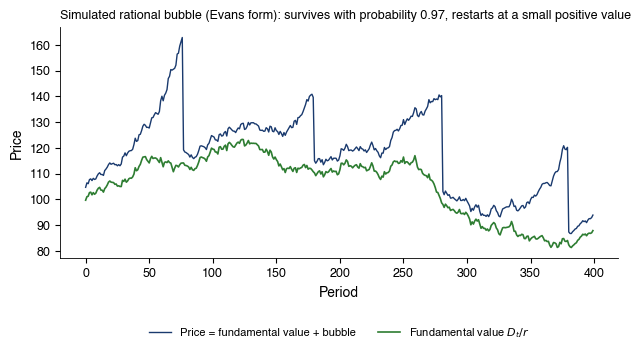

{'T': 400,
 'r': 0.01,
 'pi': 0.97,
 'b0': 5.0,
 'growth': 0.04123711340206193,
 'life': 33.33333333333331,
 'collapses': 4,
 'max_share': 0.3007730587927029,
 'max_mult': 1.4301508438353119}

In [6]:
def fig_rational_bubble():
    """Price = fundamental value (random-walk dividends, r = 1% per period) + a rational bubble that collapses
    and restarts at a positive value, in the Evans (1991) form: with probability pi = 0.97 it survives,
    B_t = [b0 + (1+r)/pi * (B_{t-1} - b0/(1+r))] u_t; otherwise B_t = b0 u_t, with E[u_t] = 1 exactly.
    The term -b0/(1+r) pays for the restart, so E_{t-1}[B_t] = (1+r) B_{t-1} exactly."""
    rng = np.random.default_rng(48)
    T, r, pi, b0, su = 400, 0.01, 0.97, 5.0, 0.03
    D = 1 + np.cumsum(0.01 * rng.standard_normal(T))
    F = D / r                                           # E_t sum D_{t+i}/(1+r)^i with random-walk dividends
    Bb = np.empty(T)
    Bb[0] = b0
    alive = rng.random(T) < pi
    u = np.exp(rng.normal(-su ** 2 / 2, su, T))         # lognormal with E[u] = 1 exactly
    for t in range(1, T):
        Bb[t] = (b0 + (1 + r) / pi * (Bb[t - 1] - b0 / (1 + r))) * u[t] if alive[t] else b0 * u[t]
    Pp = F + Bb
    collapses = int(sum(1 for t in range(1, T) if not alive[t] and Bb[t - 1] > 25))   # visible collapses (bubble > 25)
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    ax.plot(Pp, color=MainBlue, lw=1.0, label='Price = fundamental value + bubble')
    ax.plot(F, color=Forest, lw=1.2, label='Fundamental value $D_t / r$')
    ax.set_xlabel('Period')
    ax.set_ylabel('Price')
    ax.set_title('Simulated rational bubble (Evans form): survives with probability 0.97, restarts at a small positive value',
                 fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.25)
    save_fig('ch17_rational_bubble')
    return dict(T=T, r=r, pi=pi, b0=b0, growth=(1 + r) / pi - 1, life=1 / (1 - pi), collapses=collapses,
                max_share=float(np.max(Bb / Pp)), max_mult=float(np.max(Pp / F)))


fig_rational_bubble()

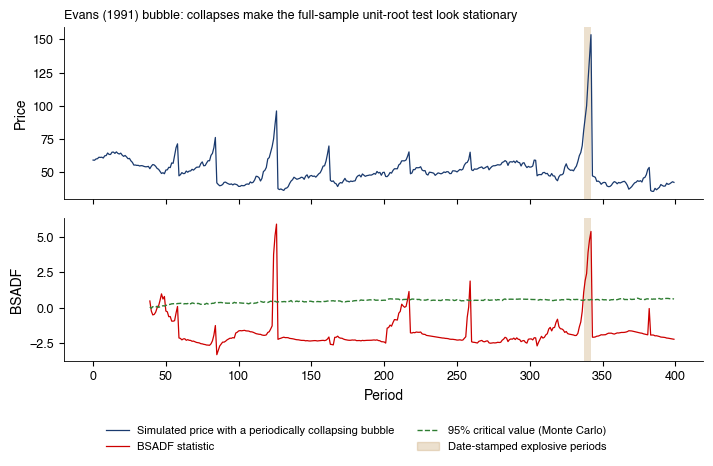

{'adf': -5.49247321092005,
 'sadf': 0.9798125427635137,
 'gsadf': 5.878808266216827,
 'cv_adf': -0.09479531243526572,
 'cv_sadf': 1.4589824017240867,
 'cv_gsadf': 2.211235749673446,
 'n_episodes': 1,
 'w0': 39,
 'T': 400}

In [7]:
def fig_evans():
    """Evans (1991) periodically collapsing bubble: full-sample ADF vs GSADF / BSADF."""
    T = 400
    B = evans_bubble(T=T, seed=11)
    rng = np.random.default_rng(5)
    D = 1 + np.cumsum(0.02 * rng.standard_normal(T))
    Pp = np.abs(D) / 0.02 + 20 * B
    y = np.log(Pp)
    res = psy(y)
    cv = psy_cv(res['n'], res['w0'], R_MC, SEED)
    L = int(np.ceil(np.log(res['n'])))
    ep = episodes(res['bsadf'], cv['bsadf95'], np.arange(1, T), L)
    fig, axes = plt.subplots(2, 1, figsize=(7.2, 4.2), sharex=True, gridspec_kw=dict(height_ratios=[1.2, 1]))
    axes[0].plot(Pp, color=MainBlue, lw=0.9, label='Simulated price with a periodically collapsing bubble')
    axes[0].set_ylabel('Price')
    axes[1].plot(np.arange(1, T), res['bsadf'], color=IDAred, lw=0.9, label='BSADF statistic')
    axes[1].plot(np.arange(1, T), cv['bsadf95'], color=Forest, lw=1.0, ls='--', label='95% critical value (Monte Carlo)')
    for s, e, _ in ep:
        for ax in axes:
            ax.axvspan(s, e if e is not None else T, color=Amber, alpha=0.25, lw=0)
    axes[1].set_xlabel('Period')
    axes[1].set_ylabel('BSADF')
    axes[0].set_title('Evans (1991) bubble: collapses make the full-sample unit-root test look stationary',
                      fontsize=9, loc='left')
    fig.tight_layout()
    axes[1].fill_between([], [], color=Amber, alpha=0.25, label='Date-stamped explosive periods')
    fig_legend(fig, axes, ncol=2, y=0.0)
    save_fig('ch17_evans')
    return dict(adf=res['adf'], sadf=res['sadf'], gsadf=res['gsadf'], cv_adf=cv['adf']['95'],
                cv_sadf=cv['sadf']['95'], cv_gsadf=cv['gsadf']['95'], n_episodes=len(ep), w0=res['w0'], T=T)


fig_evans()

## 2. Nine run-ups and crashes

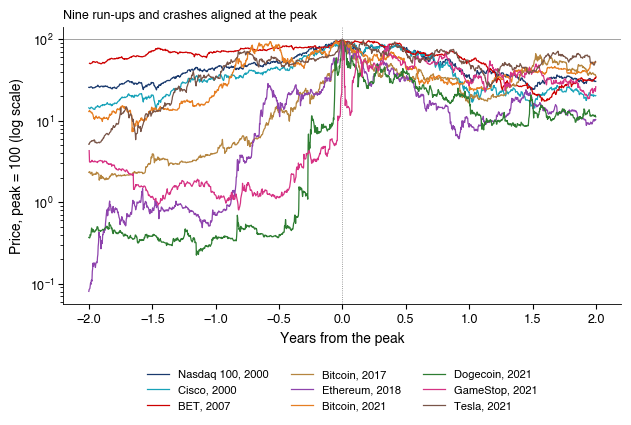

,key,label,peak,peak_price,runup2y,trough,maxdd,days_to_trough,recovered,years_to_recover
0,ndx,"Nasdaq 100, 2000",2000-03-27,4704.730000,2.882944,2002-10-07,-0.828972,924,2015-11-03,15.603012
1,csco,"Cisco, 2000",2000-03-27,51.336300,5.924331,2002-10-08,-0.892585,925,2021-08-24,21.409993
2,bet,"BET, 2007",2007-07-24,10813.590000,0.965568,2009-02-25,-0.825484,582,2021-03-16,13.645448
3,btc,"Bitcoin, 2017",2017-12-16,19497.400391,41.857647,2018-12-15,-0.833990,364,2020-11-30,2.956879
4,eth,"Ethereum, 2018",2018-01-13,1396.420044,1240.041595,2018-12-14,-0.939625,335,2021-02-02,3.055441
5,btc,"Bitcoin, 2021",2021-11-08,67566.830088,6.673793,2022-11-21,-0.766346,378,2024-03-04,2.318960
6,doge,"Dogecoin, 2021",2021-05-07,0.684777,268.973250,2022-06-18,-0.922585,407,None,NaN
7,gme,"GameStop, 2021",2021-01-27,86.877500,22.180933,2024-04-22,-0.884780,1181,None,NaN
8,tsla,"Tesla, 2021",2021-11-04,409.970000,18.370461,2023-01-03,-0.736322,425,2024-12-11,3.101985


In [8]:
EPISODES = [('ndx', 'Nasdaq 100, 2000', ('1999-01-01', '2000-12-31')), ('csco', 'Cisco, 2000', ('1999-01-01', '2000-12-31')), ('bet', 'BET, 2007', ('2006-01-01', '2008-06-30')), ('btc', 'Bitcoin, 2017', ('2017-06-01', '2018-03-31')), ('eth', 'Ethereum, 2018', ('2017-06-01', '2018-06-30')), ('btc', 'Bitcoin, 2021', ('2021-06-01', '2022-03-31')), ('doge', 'Dogecoin, 2021', ('2021-01-01', '2021-12-31')), ('gme', 'GameStop, 2021', ('2021-01-01', '2021-06-30')), ('tsla', 'Tesla, 2021', ('2021-06-01', '2022-06-30'))]


def episode_table():
    """Peak, 2-year run-up before the peak, maximum drawdown, trough and recovery."""
    rows = []
    for k, lab, (a, b) in EPISODES:
        p = price(k, 'D')
        pk = p.loc[a:b].idxmax()
        pre = p.loc[:pk]
        start = pre.index[pre.index.searchsorted(pk - pd.DateOffset(years=2))]
        post = p.loc[pk:]
        dd = post / post.iloc[0] - 1
        tr = dd.loc[:pk + pd.DateOffset(years=4)].idxmin()
        rec = post.loc[tr:][post.loc[tr:] >= post.iloc[0]]
        rows.append(dict(key=k, label=lab, peak=d2s(pk), peak_price=float(p.loc[pk]), runup2y=float(p.loc[pk] / p.loc[start] - 1),
                         trough=d2s(tr), maxdd=float(dd.loc[tr]), days_to_trough=int((tr - pk).days),
                         recovered=d2s(rec.index[0]) if len(rec) else None,
                         years_to_recover=float((rec.index[0] - pk).days / 365.25) if len(rec) else None))
    return rows


def fig_episodes(tab):
    """Episodes aligned at the peak: price normalised to 100 at the peak, +/- 2 calendar years."""
    cols = [MainBlue, Teal, IDAred, Amber, Purple, Orange, Forest, Magenta, Brown]
    fig, ax = plt.subplots(figsize=(7.2, 3.6))
    for (k, lab, _), row, c in zip(EPISODES, tab, cols):
        p = price(k, 'D')
        pk = pd.Timestamp(row['peak'])
        w = p.loc[pk - pd.DateOffset(years=2):pk + pd.DateOffset(years=2)]
        x = (w.index - pk).days / 365.25
        ax.plot(x, 100 * w.values / p.loc[pk], color=c, lw=0.9, label=lab)
    ax.set_yscale('log')
    ax.axvline(0, color=Gray, lw=0.6, ls=':')
    ax.axhline(100, color=Gray, lw=0.5)
    ax.set_xlabel('Years from the peak')
    ax.set_ylabel('Price, peak = 100 (log scale)')
    ax.set_title('Nine run-ups and crashes aligned at the peak', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=3, y=-0.2)
    save_fig('ch17_episodes')


tab = episode_table()
fig_episodes(tab)
pd.DataFrame(tab)

## 3. Bubbles for Fama: 48 US industries

- Sample of Greenwood, Shleifer and You (2019, Section 2): the first 48 Fama–French industries (without Other), industry-months with at least ten firms.
- Run-up: two-year return above a threshold, raw and net of the market, and a five-year raw return of at least 50% (from 1931); first month of the run-up, no new episode in the same industry for two years; crash: 40% drawdown within the next two years.

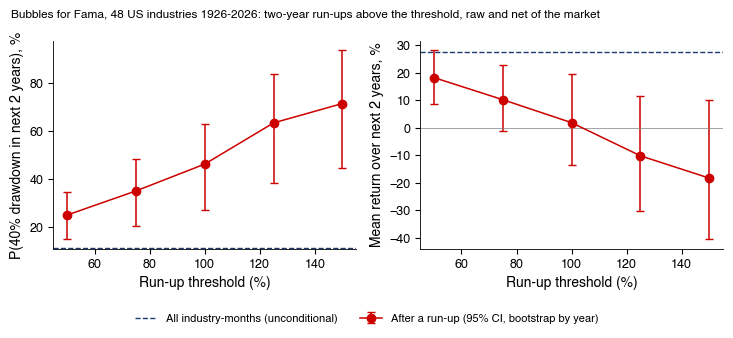

,thr,n,n_ind,crash,crash_ci,ret2,ret2_ci,first,last
0,0.50,221,47,0.248869,"[0.14771712662337663, 0.34515025811209427]",0.182005,"[0.08450748299440677, 0.2821303264037519]",1928-07-31,2024-05-31
1,0.75,103,39,0.349515,"[0.20350750720890923, 0.4815497076023388]",0.101807,"[-0.013548383571858651, 0.2271379414754339]",1928-07-31,2024-06-30
2,1.00,52,27,0.461538,"[0.27079326923076924, 0.6274509803921569]",0.018293,"[-0.1355396192806665, 0.19500038844917836]",1928-10-31,2022-05-31
3,1.25,30,21,0.633333,"[0.38095238095238093, 0.8387096774193549]",-0.101983,"[-0.3023287765660741, 0.1167302117356896]",1929-01-31,2022-05-31
4,1.50,21,16,0.714286,"[0.4444444444444444, 0.9375]",-0.183039,"[-0.40532033617413055, 0.10097523790283443]",1937-03-31,2022-08-31


In [9]:
def gsy_sample():
    """Sample of Greenwood, Shleifer & You (2019), Section 2: the first 48 Fama-French industries (without 'Other'),
    industry-months with at least ten firms."""
    ind, mkt = industries()
    firms = industry_firms().reindex(ind.index)
    ind = ind.loc[:, [c for c in ind.columns if c.strip().lower() != 'other' and ind[c].notna().mean() > 0]]
    ok = firms.reindex(columns=ind.columns) >= 10
    return ind, mkt, ok


def gsy_events(thr, H=24, crash=0.40, H5=60, r5=0.50, r5_from='1931-01-01'):
    """GSY (2019, Section 2) run-ups: 2-year return above thr, raw and net of the market, and a 5-year raw return
    of at least 50% (imposed from 1931); first month of the run-up, no new episode in the same industry for 2 years;
    crash = a 40% fall from a previous peak within the next 2 years."""
    ind, mkt, ok = gsy_sample()
    Pm = (1 + mkt.reindex(ind.index)).cumprod()
    runm = Pm / Pm.shift(H) - 1
    rows = []
    for c in ind.columns:
        r = ind[c]
        valid = r.notna()
        p = (1 + r.fillna(0)).cumprod()
        run = p / p.shift(H) - 1
        run5 = p / p.shift(H5) - 1
        five = (run5 >= r5) | (ind.index < pd.Timestamp(r5_from))
        cond = ((run > thr) & ((run - runm) > thr) & five & ok[c] & valid & valid.shift(H, fill_value=False))
        last = None
        for i in np.where(cond.values)[0]:
            if (last is not None and i - last < H) or i + H >= len(p):
                continue
            fut = p.iloc[i:i + H + 1].values
            rows.append(dict(ind=c, date=p.index[i], run=float(run.iloc[i]),
                             mdd=float((fut / np.maximum.accumulate(fut) - 1).min()), ret2=float(fut[-1] / fut[0] - 1)))
            last = i
    d = pd.DataFrame(rows)
    d['crash'] = d['mdd'] <= -crash
    return d


def gsy_unconditional(H=24, crash=0.40):
    """Unconditional probability of a 40% fall within 2 years (all industry-months of the GSY sample)."""
    ind, _, ok = gsy_sample()
    hits, n, rets = 0, 0, []
    for c in ind.columns:
        r = ind[c]
        p = (1 + r.fillna(0)).cumprod().values
        v = (r.notna() & ok[c]).values
        for i in range(len(p) - H):
            if not v[i]:
                continue
            fut = p[i:i + H + 1]
            hits += (fut / np.maximum.accumulate(fut) - 1).min() <= -crash
            rets.append(fut[-1] / fut[0] - 1)
            n += 1
    return hits / n, float(np.mean(rets)), n


def cluster_boot(d, col, B=2000, seed=SEED):
    """95% bootstrap interval resampling calendar years (episodes in the same year are correlated)."""
    rng = np.random.default_rng(seed)
    g = {y: grp[col].values for y, grp in d.groupby(d['date'].dt.year)}
    keys = list(g)
    stats = []
    for _ in range(B):
        pick = rng.choice(len(keys), len(keys), replace=True)
        v = np.concatenate([g[keys[j]] for j in pick])
        stats.append(v.mean())
    return [float(np.quantile(stats, 0.025)), float(np.quantile(stats, 0.975))]


def fig_gsy():
    thrs = [0.5, 0.75, 1.0, 1.25, 1.5]
    pu, ru, nu = gsy_unconditional()
    out = dict(uncond_crash=pu, uncond_ret2=ru, n_months=nu, rows=[])
    for th in thrs:
        d = gsy_events(th)
        out['rows'].append(dict(thr=th, n=int(len(d)), n_ind=int(d['ind'].nunique()), crash=float(d['crash'].mean()),
                                crash_ci=cluster_boot(d, 'crash'), ret2=float(d['ret2'].mean()),
                                ret2_ci=cluster_boot(d, 'ret2'), first=d2s(d['date'].min()), last=d2s(d['date'].max())))
    R = pd.DataFrame(out['rows'])
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0))
    x = 100 * R['thr']
    lo = np.array([c[0] for c in R['crash_ci']])
    hi = np.array([c[1] for c in R['crash_ci']])
    axes[0].errorbar(x, 100 * R['crash'], yerr=[100 * (R['crash'] - lo), 100 * (hi - R['crash'])], fmt='o-',
                     color=IDAred, capsize=3, label='After a run-up (95% CI, bootstrap by year)')
    axes[0].axhline(100 * pu, color=MainBlue, ls='--', lw=1.0, label='All industry-months (unconditional)')
    axes[0].set_xlabel('Run-up threshold (%)')
    axes[0].set_ylabel('P(40% drawdown in next 2 years), %')
    lo = np.array([c[0] for c in R['ret2_ci']])
    hi = np.array([c[1] for c in R['ret2_ci']])
    axes[1].errorbar(x, 100 * R['ret2'], yerr=[100 * (R['ret2'] - lo), 100 * (hi - R['ret2'])], fmt='o-',
                     color=IDAred, capsize=3)
    axes[1].axhline(100 * ru, color=MainBlue, ls='--', lw=1.0)
    axes[1].axhline(0, color=Gray, lw=0.5)
    axes[1].set_xlabel('Run-up threshold (%)')
    axes[1].set_ylabel('Mean return over next 2 years, %')
    fig.suptitle('Bubbles for Fama, 48 US industries 1926-2026: two-year run-ups above the threshold, raw and net of the market',
                 fontsize=8.5, x=0.02, ha='left')
    fig.tight_layout()
    fig_legend(fig, axes, ncol=2, y=0.0)
    save_fig('ch17_gsy')
    return out


res = fig_gsy()
pd.DataFrame(res['rows'])

## 4. Windows and null distributions

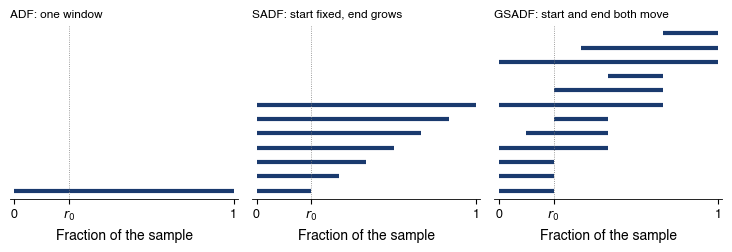

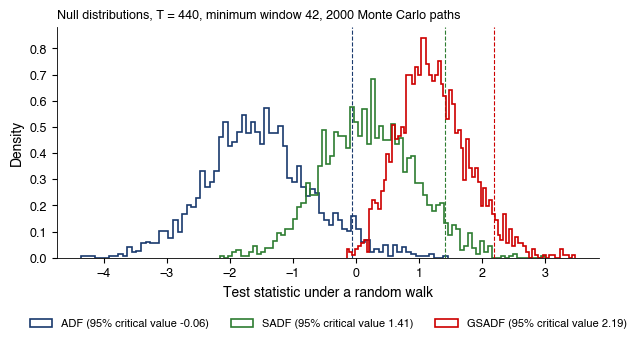

{'adf': {'90': -0.44019069100256664,
  '95': -0.06104151866652127,
  '99': 0.6525273541791642},
 'sadf': {'90': 1.1674363323454702,
  '95': 1.4103426039958415,
  '99': 1.975277982512124},
 'gsadf': {'90': 1.9614984190261007,
  '95': 2.187861617328365,
  '99': 2.64984740456162}}

In [10]:
def fig_windows():
    """Schema ferestrelor: ADF (toata selectia), SADF (inceput fix, sfarsit variabil), GSADF (ambele variabile)."""
    fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.6), sharey=True)
    specs = [('ADF: one window', [(0, 1)]),
             ('SADF: start fixed, end grows', [(0, e) for e in np.linspace(0.25, 1, 7)]),
             ('GSADF: start and end both move', [(s, e) for e in np.linspace(0.25, 1, 4) for s in np.linspace(0, e - 0.25, 3)])]
    for ax, (title, wins) in zip(axes, specs):
        for i, (s, e) in enumerate(wins):
            ax.plot([s, e], [i, i], color=MainBlue if 'ADF:' in title else (Forest if 'SADF:' in title else IDAred), lw=3,
                    solid_capstyle='butt')
        ax.axvline(0.25, color=Gray, lw=0.6, ls=':')
        ax.set_title(title, fontsize=8.5, loc='left')
        ax.set_xlim(-0.02, 1.02)
        ax.set_xticks([0, 0.25, 1])
        ax.set_xticklabels(['0', '$r_0$', '1'])
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)
        ax.set_xlabel('Fraction of the sample')
    fig.tight_layout()
    save_fig('ch17_windows')


def fig_null(cv, T):
    """Null (random-walk) distributions of ADF, SADF and GSADF, with their 95% critical values."""
    fig, ax = plt.subplots(figsize=(7.0, 3.0))
    for k, c, lab in [('adf', MainBlue, 'ADF'), ('sadf', Forest, 'SADF'), ('gsadf', IDAred, 'GSADF')]:
        v = cv['null'][k]
        ax.hist(v, bins=80, density=True, histtype='step', color=c, lw=1.2, label=f'{lab} (95% critical value {cv[k]["95"]:.2f})')
        ax.axvline(cv[k]['95'], color=c, ls='--', lw=0.8)
    ax.set_xlabel('Test statistic under a random walk')
    ax.set_ylabel('Density')
    ax.set_title(f'Null distributions, T = {T}, minimum window {cv["w0"]}, {cv["R"]} Monte Carlo paths', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=3, y=-0.22)
    save_fig('ch17_null')


fig_windows()
y_ndx = np.log(price('ndx', 'M'))
o_ndx = run_psy(y_ndx)
fig_null(o_ndx['cv'], o_ndx['res']['n'])
{k: o_ndx['cv'][k] for k in ['adf', 'sadf', 'gsadf']}

## 5. S&P 500 price-dividend ratio, 1871 to the latest month

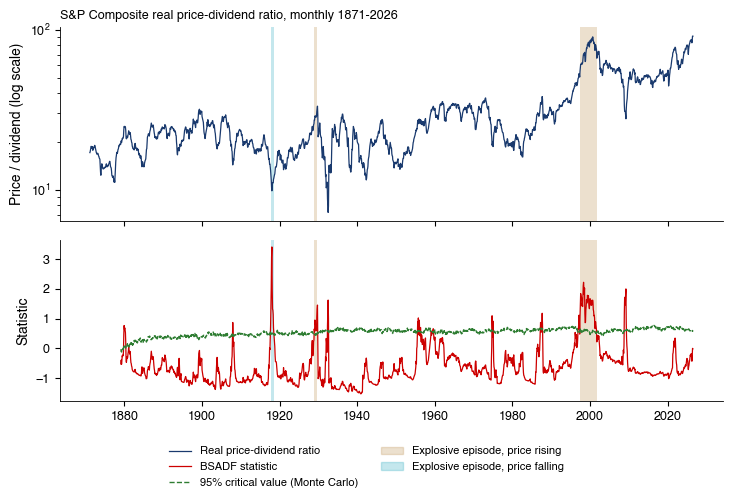

[{'start': '1917-08-31',
  'end': '1918-06-30',
  'n': 11,
  'change': -0.10346024302647994},
 {'start': '1928-11-30',
  'end': '1929-09-30',
  'n': 11,
  'change': 0.2176971268291783},
 {'start': '1997-05-31',
  'end': '2001-08-31',
  'n': 52,
  'change': 0.36093454404225556}]

In [11]:
sh = shiller()
y_pd = np.log(sh['PD'])
o_pd = run_psy(y_pd, R=1000)
fig_psy(y_pd, o_pd, 'ch17_sp_pd', f'S&P Composite real price-dividend ratio, monthly {sh.index[0].year}-{sh.index[-1].year}', 'Price / dividend (log scale)', level=sh['PD'], level_label='Real price-dividend ratio')
summarise(o_pd, y_pd)['episodes']

## 6. Nasdaq 100, Bitcoin, BET and GameStop

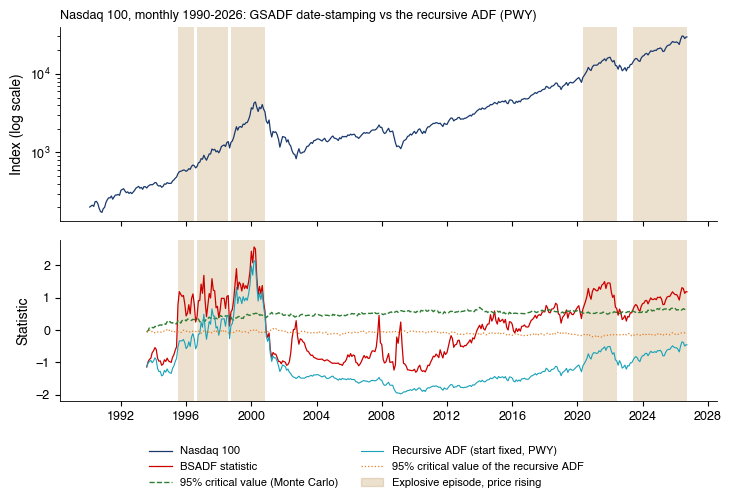

,start,end,peak,lead_days,change,gain_to_peak,dd_after,signal_end_after_peak_days
0,1995-06-30,1996-06-30,1996-12-09,528,0.258852,0.592179,-0.084890,-162.0
1,1996-08-31,1998-07-31,1999-01-29,881,1.075531,2.205675,-0.112134,-182.0
2,1998-09-30,2000-10-31,2000-03-27,544,1.439501,2.496693,-0.760464,218.0
3,2020-04-30,2022-05-31,2021-11-19,568,0.404598,0.841378,-0.355631,193.0
4,2023-05-31,None,2026-06-02,1098,1.079696,1.151004,-0.113119,NaN


In [12]:
fig_psy(y_ndx, o_ndx, 'ch17_ndx', 'Nasdaq 100, monthly 1990-2026: GSADF date-stamping vs the recursive ADF (PWY)', 'Index (log scale)', pwy=True, level_label='Nasdaq 100')
pd.DataFrame(real_time(o_ndx, price('ndx', 'D')))

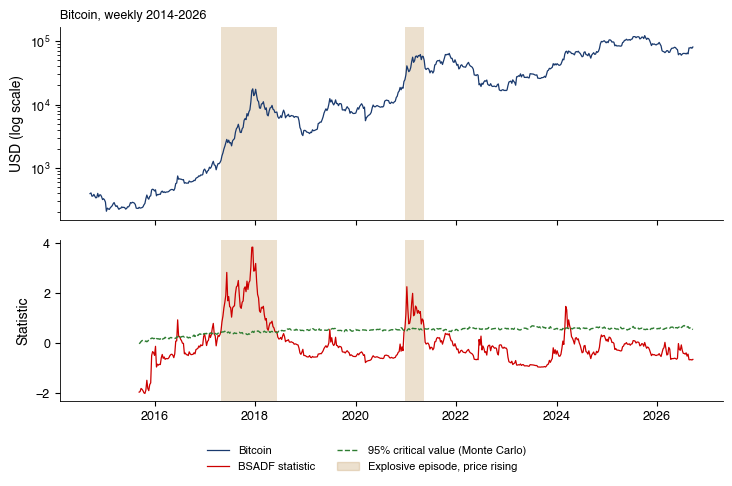

3.848666319133873 {'90': 2.011965367670432, '95': 2.2705159532859884, '99': 2.6910831812657494} 2.8225047174576106


,start,end,peak,lead_days,change,gain_to_peak,dd_after,signal_end_after_peak_days
0,2017-04-28,2018-06-08,2017-12-16,232,4.791900,13.810252,-0.833990,174
1,2020-12-25,2021-05-14,2021-11-08,318,1.022338,1.739404,-0.766346,-178


In [13]:
y_btc = np.log(price('btc', 'W'))
o_btc = run_psy(y_btc, wild=True)
fig_psy(y_btc, o_btc, 'ch17_btc', 'Bitcoin, weekly 2014-2026', 'USD (log scale)', level_label='Bitcoin')
s = summarise(o_btc, y_btc)
print(s['gsadf'], s['cv_gsadf'], s['cv_gsadf_wild'])
pd.DataFrame(real_time(o_btc, price('btc', 'D')))

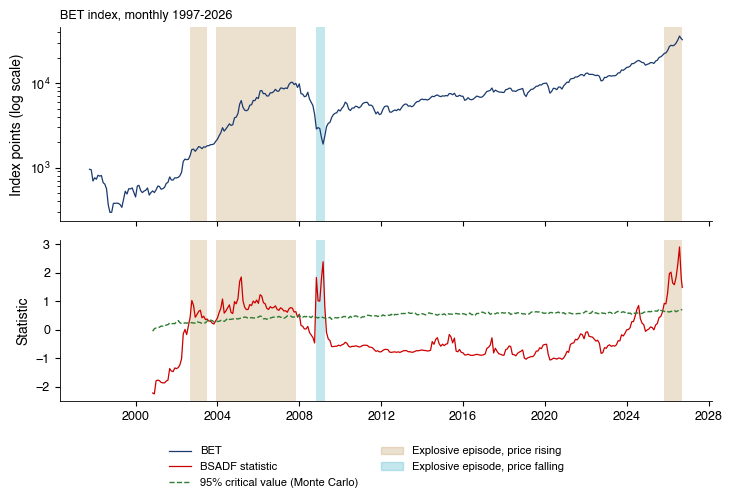

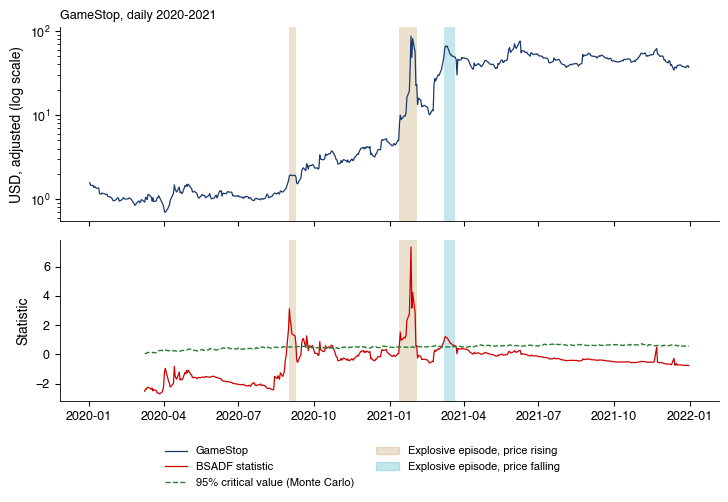

,start,end,peak,lead_days,change,gain_to_peak,dd_after,signal_end_after_peak_days
0,2002-08-31,2003-06-30,2003-12-19,475,0.300800,0.558780,0.000000,-172.0
1,2003-11-30,2007-10-31,2007-07-24,1332,3.868541,4.291027,-0.825484,99.0
2,2008-10-31,2009-03-31,2009-09-23,327,-0.174047,0.550575,-0.072155,-176.0
3,2025-10-31,None,2026-08-19,292,0.454817,0.620445,-0.131387,NaN


In [14]:
y_bet = np.log(price('bet', 'M'))
o_bet = run_psy(y_bet)
fig_psy(y_bet, o_bet, 'ch17_bet', 'BET index, monthly 1997-2026', 'Index points (log scale)', level_label='BET')
y_gme = np.log(price('gme', 'D', '2020-01-01', '2021-12-31'))
o_gme = run_psy(y_gme)
fig_psy(y_gme, o_gme, 'ch17_gme', 'GameStop, daily 2020-2021', 'USD, adjusted (log scale)', level_label='GameStop')
pd.DataFrame(real_time(o_bet, price('bet', 'D')))

## 7. Real time vs hindsight: first signal and peak

- Start (column `first`): start of the episode, dated in hindsight; confirmation (column `confirm`): the date on which $L = \lceil \ln T \rceil$ consecutive exceedances make the episode known in real time.

In [15]:
pd.DataFrame({
    'Nasdaq 100, monthly': signal_vs_peak(o_ndx, price('ndx', 'D'), ('1999-01-01', '2000-12-31'), 93),
    'BET, monthly': signal_vs_peak(o_bet, price('bet', 'D'), ('2006-01-01', '2008-06-30'), 93),
    'Bitcoin 2017, weekly': signal_vs_peak(o_btc, price('btc', 'D'), ('2017-06-01', '2018-03-31'), 28),
    'Bitcoin 2021, weekly': signal_vs_peak(o_btc, price('btc', 'D'), ('2021-01-01', '2021-06-30'), 28),
    'GameStop 2021, daily': signal_vs_peak(o_gme, price('gme', 'D'), ('2021-01-01', '2021-06-30'), 10, dd_years=1)}).T

,first,peak,lead_days,lead_months,confirm,lead_confirm_days,lead_confirm_months,gain,gain_confirm,dd_after,signal_end
"Nasdaq 100, monthly",1995-06-30,2000-03-27,1732,56.898817,1995-12-31,1548,50.854139,7.744364,7.164674,-0.760464,2000-10-31
"BET, monthly",2003-11-30,2007-07-24,1332,43.758213,2004-04-30,1180,38.764783,4.291027,2.994972,-0.825484,2007-10-31
"Bitcoin 2017, weekly",2017-04-28,2017-12-16,232,7.621551,2017-06-09,190,6.241787,13.810252,5.904643,-0.83399,2018-06-08
"Bitcoin 2021, weekly",2020-12-25,2021-04-13,109,3.580815,2021-02-05,67,2.201051,1.57466,0.664821,-0.751395,2021-05-14
"GameStop 2021, daily",2021-01-13,2021-01-27,14,0.459921,2021-01-22,5,0.164258,10.067197,4.345485,-0.883198,2021-02-03


## 8. LPPLS: Bitcoin 2017 and the instability of the critical time

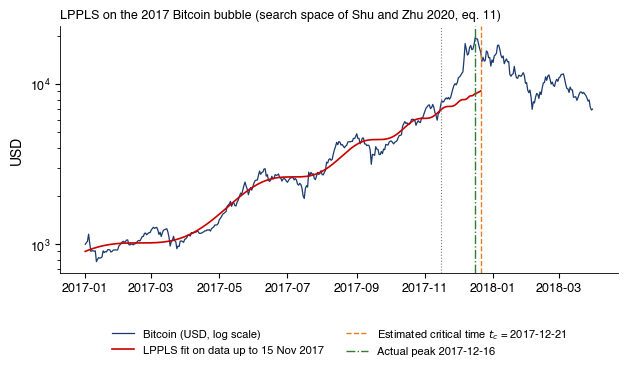

{'tc': 2017.9697662007775, 'm': 0.9541806959262238, 'w': 10.54352508820123, 'A': 9.114254734426792, 'B': -2.6150974174412482, 'C1': 0.21833417525511808, 'C2': -0.09132445388181863, 'C': 0.23666425154878173, 'ssr': 3.494048383231588, 'rmse': 0.1046572010326987, 'damping': 1.0000000000016085, 'osc': 7.654029184936746, 'rel_err': 0.42403682847050617, 't1': '2017-01-01', 't2': '2017-11-15', 'tc_date': '2017-12-21', 'peak': '2017-12-16', 'qualified': False, 'cond': {'B': True, 'm': True, 'w': True, 'tc': True, 'osc': True, 'damping': True, 'rel_err': False, 'lomb': None, 'ar1': None}, 'lomb_p': 0.0, 'n': 319}


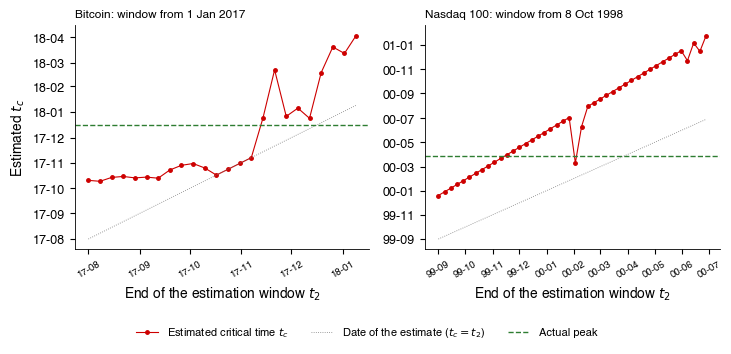

{'btc': {'peak': '2017-12-16',
  'n': 24,
  'n_before': 20,
  'mae_days': 48.15,
  'med_err_days': -52.5,
  'min_tc': '2017-10-09',
  'max_tc': '2018-02-20',
  'share_within_30': 0.2,
  'share_qualified': 0.0},
 'ndx': {'peak': '2000-03-27',
  'n': 44,
  'n_before': 30,
  'mae_days': 70.36666666666666,
  'med_err_days': 26.5,
  'min_tc': '1999-12-19',
  'max_tc': '2000-09-15',
  'share_within_30': 0.23333333333333334,
  'share_qualified': 0.0}}

In [16]:
def fig_lppls_btc2017():
    """LPPLS fitted to Bitcoin 2017-01-01 .. 2017-11-15 and the observed path up to March 2018."""
    p = price('btc', 'D')
    t1, t2 = '2017-01-01', '2017-11-15'
    w = p.loc[t1:t2]
    f = lppls_fit(yrs(w.index), np.log(w.values))
    full = p.loc[t1:'2018-03-31']
    tt = yrs(full.index)
    mask = tt < f['tc']
    fig, ax = plt.subplots(figsize=(7.2, 3.2))
    ax.plot(full.index, full.values, color=MainBlue, lw=0.9, label='Bitcoin (USD, log scale)')
    ax.plot(full.index[mask], np.exp(lppls_path(f, tt[mask])), color=IDAred, lw=1.2, label='LPPLS fit on data up to 15 Nov 2017')
    ax.axvline(pd.Timestamp(t2), color=Gray, ls=':', lw=0.8)
    ax.axvline(todate(f['tc']), color=Orange, ls='--', lw=1.0, label=f"Estimated critical time $t_c$ = {todate(f['tc']).date()}")
    pk = p.loc['2017'].idxmax()
    ax.axvline(pk, color=Forest, ls='-.', lw=1.0, label=f'Actual peak {pk.date()}')
    ax.set_yscale('log')
    ax.set_ylabel('USD')
    ax.set_title('LPPLS on the 2017 Bitcoin bubble (search space of Shu and Zhu 2020, eq. 11)', fontsize=9, loc='left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    legend_outside_bottom(ax, ncol=2, y=-0.18)
    save_fig('ch17_lppls_btc2017')
    cond = lppls_conditions(f)
    out = {k: v for k, v in f.items() if not k.startswith('_')}
    out.update(tc_date=d2s(todate(f['tc'])), peak=d2s(pk), t1=t1, t2=t2, qualified=lppls_qualified(f), cond=cond,
               lomb_p=lomb_pvalue(f), n=int(len(w)))
    return out


def tc_path(key, t1, t2_from, t2_to, step_days=7):
    """tc estimated on windows [t1, t2] with a moving t2 (every step_days days)."""
    p = price(key, 'D')
    rows = []
    for t2 in pd.date_range(t2_from, t2_to, freq=f'{step_days}D'):
        w = p.loc[t1:t2]
        f = lppls_fit(yrs(w.index), np.log(w.values))
        rows.append(dict(t2=w.index[-1], tc=todate(f['tc']), m=f['m'], w=f['w'], q=lppls_qualified(f)))
    return pd.DataFrame(rows)


def fig_tc_instability():
    cases = [('btc', 'Bitcoin: window from 1 Jan 2017', '2017-01-01', '2017-08-01', '2018-01-15', ('2017-06-01', '2018-03-31')),
             ('ndx', 'Nasdaq 100: window from 8 Oct 1998', '1998-10-08', '1999-09-01', '2000-06-30', ('1999-06-01', '2000-12-31'))]
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.2))
    out = {}
    for ax, (k, title, t1, a, b, (pa, pb)) in zip(axes, cases):
        d = tc_path(k, t1, a, b)
        pk = price(k, 'D').loc[pa:pb].idxmax()
        ax.plot(d['t2'], d['tc'], 'o-', color=IDAred, ms=2.5, lw=0.8, label='Estimated critical time $t_c$')
        ax.plot(d['t2'], d['t2'], color=Gray, lw=0.6, ls=':', label='Date of the estimate ($t_c = t_2$)')
        ax.axhline(pk, color=Forest, ls='--', lw=1.0, label='Actual peak')
        ax.set_title(title, fontsize=8.5, loc='left')
        ax.set_xlabel('End of the estimation window $t_2$')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
        ax.yaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        err = (d['tc'] - pk).dt.days
        before = d['t2'] < pk
        out[k] = dict(peak=d2s(pk), n=int(len(d)), n_before=int(before.sum()),
                      mae_days=float(err[before].abs().mean()), med_err_days=float(err[before].median()),
                      min_tc=d2s(d.loc[before, 'tc'].min()), max_tc=d2s(d.loc[before, 'tc'].max()),
                      share_within_30=float((err[before].abs() <= 30).mean()), share_qualified=float(d.loc[before, 'q'].mean()))
    axes[0].set_ylabel('Estimated $t_c$')
    fig.tight_layout()
    fig_legend(fig, axes, ncol=3, y=0.0)
    save_fig('ch17_tc_instability')
    return out


print(fig_lppls_btc2017())
fig_tc_instability()

## 9. LPPLS confidence indicator

- Computing the confidence indicator takes several minutes; set `RECOMPUTE = True` to recompute it, otherwise precomputed values are used.

In [17]:
COND_LABELS = {'B': 'B < 0', 'm': 'm in [0.01, 0.99]', 'w': 'omega in [2, 25]', 'tc': 'tc in [t2, t2 + (t2-t1)/5]', 'osc': 'oscillations >= 2.5', 'damping': 'damping >= 1', 'rel_err': 'max relative error <= 0.15', 'lomb': 'Lomb test, 10% (cumulative)', 'ar1': 'residual unit root rejected, 10% (cumulative)'}


def _ci_worker(args):
    """All 141 windows for one t2: the indicator and the number of windows passing each condition."""
    t, y, i = args
    cnt = dict.fromkeys(COND_LABELS, 0)
    q, n = 0, 0
    for L in LPPLS_WINDOWS:
        if i - L < 0:
            continue
        f = lppls_fit(t[i - L:i + 1], y[i - L:i + 1])
        c = lppls_conditions(f)
        n += 1
        if c is None:
            continue
        for k, v in c.items():
            cnt[k] += v is True
        q += all(v is True for v in c.values())
    return q / n, cnt, n


def confidence_series(key, start, t2_from, step=LPPLS_STEP, procs=None):
    """LPPLS confidence indicator (Shu & Zhu 2020): t2 every 5 observations, 141 windows of 750 to 50 observations."""
    from multiprocessing import Pool
    p = price(key, 'D', start)
    t, y = yrs(p.index), np.log(p.values)
    i0 = int(p.index.searchsorted(pd.Timestamp(t2_from)))
    idx = np.arange(max(i0, max(LPPLS_WINDOWS)), len(p), step)
    with Pool(procs or max(1, (os.cpu_count() or 2) - 2)) as pool:
        res = pool.map(_ci_worker, [(t, y, i) for i in idx], chunksize=4)
    df = pd.DataFrame([dict(ci=r[0], n=r[2], **{f'pass_{k}': v for k, v in r[1].items()}) for r in res], index=p.index[idx])
    df.index.name = 'date'
    return df


def ci_evaluation(ci, p, horizon=90, fall=0.20):
    """Signal (indicator > 0) vs a fall of at least 20% below the current price within the next 90 days;
    only dates whose 90 calendar days are fully observed."""
    rows = []
    for d, v in ci.items():
        if d + pd.Timedelta(days=horizon) > p.index[-1]:
            continue
        fut = p.loc[d:d + pd.Timedelta(days=horizon)]
        rows.append(dict(date=d, ci=v, hit=bool(fut.min() / fut.iloc[0] - 1 <= -fall)))
    r = pd.DataFrame(rows)
    on, off = r[r.ci > 0], r[r.ci == 0]
    return dict(n=int(len(r)), n_on=int(len(on)), p_on=float(on.hit.mean()) if len(on) else None,
                p_off=float(off.hit.mean()), base=float(r.hit.mean()), horizon=horizon, fall=fall)


def condition_shares(tab):
    """Share of windows (over all t2 dates) passing each condition, taken separately."""
    n = tab['n'].sum()
    return {k: float(tab[f'pass_{k}'].sum() / n) for k in COND_LABELS}


def fig_lppls_ci(tab_btc, tab_ndx):
    fig, axes = plt.subplots(2, 1, figsize=(7.4, 4.0), gridspec_kw=dict(height_ratios=[1.2, 1]))
    p = price('btc', 'D', '2015-01-01')
    ax = axes[0]
    ax.plot(p.index, p.values, color=MainBlue, lw=0.8, label='Bitcoin (USD, log scale)')
    ax.set_yscale('log')
    ax2 = ax.twinx()
    ax2.bar(tab_btc.index, tab_btc['ci'], width=6, color=IDAred, label='LPPLS confidence indicator (right axis)')
    ax2.set_ylim(0, 1)
    ax2.spines['right'].set_visible(True)
    ax.set_title('Bitcoin: LPPLS confidence indicator, 141 windows of 50-750 days, every 5 days', fontsize=9, loc='left')
    keys = list(COND_LABELS)
    sb, sn = condition_shares(tab_btc), condition_shares(tab_ndx)
    x = np.arange(len(keys))
    axes[1].bar(x - 0.2, [100 * sb[k] for k in keys], 0.4, color=Amber, label='Bitcoin, all windows')
    axes[1].bar(x + 0.2, [100 * sn[k] for k in keys], 0.4, color=Teal, label='Nasdaq 100, all windows')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([COND_LABELS[k] for k in keys], rotation=20, ha='right', fontsize=6.5)
    axes[1].set_ylabel('% of windows passing')
    fig.tight_layout()
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    h3, l3 = axes[1].get_legend_handles_labels()
    fig.legend(h1 + h2 + h3, l1 + l2 + l3, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=False)
    save_fig('ch17_lppls_ci')

In [18]:
def get_ci(key, start, t2_from, fname):
    """LPPLS confidence indicator: recomputed (RECOMPUTE = True, several minutes) or precomputed values."""
    if RECOMPUTE:
        return confidence_series(key, start, t2_from)
    path = os.path.join(HERE, fname)
    return pd.read_csv(path if os.path.exists(path) else QL_RAW + fname, index_col=0, parse_dates=True)

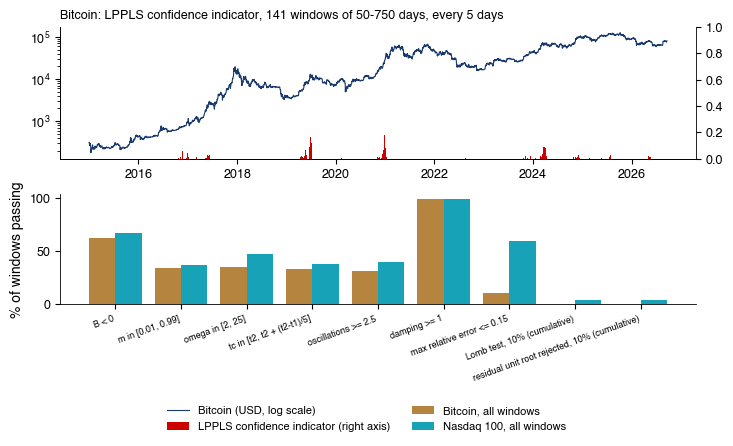

{'n': 709, 'n_on': 82, 'p_on': 0.21951219512195122, 'p_off': 0.3748006379585327, 'base': 0.35684062059238364, 'horizon': 90, 'fall': 0.2}


{'n': 1482, 'n_on': 636, 'p_on': 0.036163522012578615, 'p_off': 0.10756501182033097, 'base': 0.07692307692307693, 'horizon': 90, 'fall': 0.2}


In [19]:
tab_btc = get_ci('btc', '2014-09-17', '2016-10-01', 'ch17_lppls_ci_btc.csv')
tab_ndx = get_ci('ndx', '1994-01-01', '1997-01-01', 'ch17_lppls_ci_ndx.csv')
fig_lppls_ci(tab_btc, tab_ndx)
print(ci_evaluation(tab_btc['ci'], price('btc', 'D')))
print(ci_evaluation(tab_ndx['ci'], price('ndx', 'D')))

## 9b. Is the indicator better than chance? Dependence-robust test

- Only dates whose 90 calendar days are fully observed; circular block bootstrap of (signal, outcome) pairs with 90-day blocks; linear probability regression with Newey–West standard errors.

In [20]:
def lppls_hits(ci, p, horizon=90, fall=0.20):
    """Only dates whose `horizon` calendar days are fully observed (no censored outcomes at the end)."""
    rows = []
    for d, v in ci.items():
        if d + pd.Timedelta(days=horizon) > p.index[-1]:
            continue
        fut = p.loc[d:d + pd.Timedelta(days=horizon)]
        rows.append(dict(date=d, sig=float(v > 0), hit=float(fut.min() / fut.iloc[0] - 1 <= -fall)))
    return pd.DataFrame(rows).set_index('date')


def circular_block_ci(s, h, block, B=9999, seed=SEED):
    """Circular block bootstrap of the (signal, outcome) pairs: distribution of the difference p_on - p_off."""
    rng = np.random.default_rng(seed)
    n = len(s)
    k = int(np.ceil(n / block))
    st = rng.integers(0, n, size=(B, k))
    ix = ((st[:, :, None] + np.arange(block)[None, None, :]) % n).reshape(B, -1)[:, :n]
    S, H = s[ix], h[ix]
    non = S.sum(1)
    ok = (non > 0) & (non < n)
    d = (H * S).sum(1)[ok] / non[ok] - (H * (1 - S)).sum(1)[ok] / (n - non[ok])
    return d


def hac_lpm(s, h, lags):
    """Linear probability regression h = a + b s + u, Newey-West standard error with `lags` lags."""
    import statsmodels.api as sm
    X = sm.add_constant(s)
    r = sm.OLS(h, X).fit(cov_type='HAC', cov_kwds=dict(maxlags=lags))
    return dict(b=float(r.params[1]), se=float(r.bse[1]), t=float(r.tvalues[1]), p=float(r.pvalues[1]))


d = lppls_hits(tab_btc['ci'], price('btc', 'D'))
block = 18   # 90 days / 5 days between dates
bd = circular_block_ci(d['sig'].values, d['hit'].values, block)
print('diff', d.loc[d.sig == 1, 'hit'].mean() - d.loc[d.sig == 0, 'hit'].mean(), 'CI', np.quantile(bd, [0.025, 0.975]))
hac_lpm(d['sig'].values, d['hit'].values, block)

diff -0.15528844283658147 CI [-0.2995683   0.01795281]


{'b': -0.15528844283657978,
 'se': 0.07875573305277998,
 't': -1.9717731880231453,
 'p': 0.04863550441277417}

## 10. Markov-switching regimes

- The parameters are estimated on the full sample, so the filtered probabilities are pseudo real time (filtered given full-sample parameters).

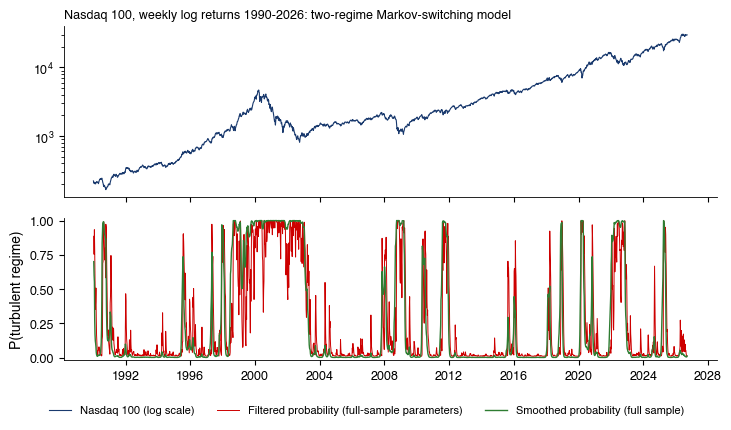

{'n': 1915,
 'start': '1990-01-12',
 'end': '2026-09-18',
 'llf': -4773.916663780611,
 'aic': 9559.833327561222,
 'bic': 9593.17816497091,
 'calm': {'mu': 0.43272178824381063,
  'mu_se': 0.0649260200513403,
  'sd': 2.295642737162139,
  'stay': 0.9867397230865341,
  'dur': 75.41320641535738,
  'share': 0.7648243527591474},
 'turb': {'mu': -0.32134230422463006,
  'mu_se': 0.26951760923233453,
  'sd': 5.397153045639892,
  'stay': 0.9573693402228619,
  'dur': 23.457295881127287,
  'share': 0.23517564724085385}}

In [21]:
def ms_fit(key, start, freq='W', k=2):
    """Markov switching: regime-specific mean and variance, weekly log returns in %."""
    import statsmodels.api as sm
    p = price(key, freq, start)
    r = 100 * np.log(p).diff().dropna()
    np.random.seed(SEED)                              # random search over starting values: reproducible
    res = sm.tsa.MarkovRegression(r, k_regimes=k, trend='c', switching_variance=True).fit(search_reps=20, disp=False)
    hi = int(np.argmax([res.params[f'sigma2[{j}]'] for j in range(k)]))
    return p, r, res, hi


def ms_summary(res, hi, r, k=2):
    par = res.params
    se = res.bse
    lo = 1 - hi if k == 2 else None
    P = np.asarray(res.regime_transition)[:, :, 0]         # statsmodels stores P[i, j] = P(s_t = i | s_{t-1} = j)
    out = dict(n=int(len(r)), start=d2s(r.index[0]), end=d2s(r.index[-1]), llf=float(res.llf), aic=float(res.aic),
               bic=float(res.bic))
    for j, tag in [(lo, 'calm'), (hi, 'turb')]:
        out[tag] = dict(mu=float(par[f'const[{j}]']), mu_se=float(se[f'const[{j}]']),
                        sd=float(np.sqrt(par[f'sigma2[{j}]'])), stay=float(P[j, j]),
                        dur=float(res.expected_durations[j]), share=float(res.smoothed_marginal_probabilities[j].mean()))
    return out


def fig_ms(key, start, name, title):
    p, r, res, hi = ms_fit(key, start)
    fp = res.filtered_marginal_probabilities[hi]
    sp = res.smoothed_marginal_probabilities[hi]
    fig, axes = plt.subplots(2, 1, figsize=(7.4, 4.0), sharex=True, gridspec_kw=dict(height_ratios=[1.2, 1]))
    axes[0].plot(p.index, p.values, color=MainBlue, lw=0.8, label=f'{LABELS[key]} (log scale)')
    axes[0].set_yscale('log')
    axes[1].plot(fp.index, fp.values, color=IDAred, lw=0.7, label='Filtered probability (full-sample parameters)')
    axes[1].plot(sp.index, sp.values, color=Forest, lw=1.0, label='Smoothed probability (full sample)')
    axes[1].set_ylabel('P(turbulent regime)')
    axes[1].set_ylim(-0.02, 1.02)
    axes[0].set_title(title, fontsize=9, loc='left')
    fig.tight_layout()
    fig_legend(fig, axes, ncol=3, y=0.0)
    save_fig(name)
    out = ms_summary(res, hi, r)
    # filtered probability at the peaks and 3 months later
    return out, fp, sp


ms_ndx, fp_ndx, sp_ndx = fig_ms('ndx', '1990-01-01', 'ch17_ms_ndx', 'Nasdaq 100, weekly log returns 1990-2026: two-regime Markov-switching model')
ms_ndx

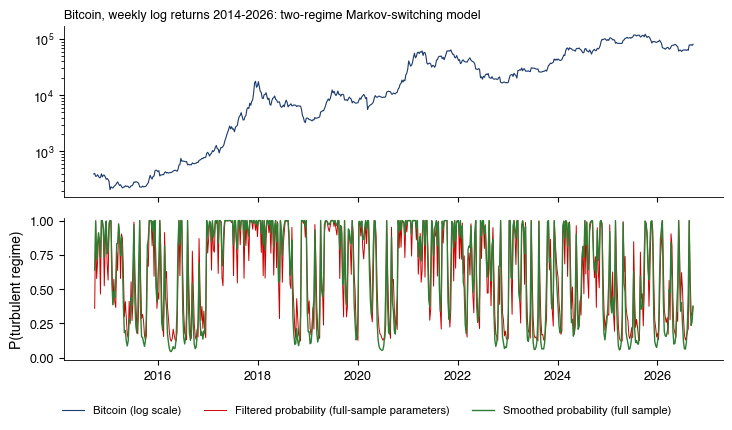

{'n': 626,
 'start': '2014-09-26',
 'end': '2026-09-18',
 'llf': -2205.839723547048,
 'aic': 4423.679447094096,
 'bic': 4450.315549320697,
 'calm': {'mu': 0.2622398128099182,
  'mu_se': 0.27955480011355455,
  'sd': 2.925835214727348,
  'stay': 0.7356629487034172,
  'dur': 3.7830489335299906,
  'share': 0.3764592085128543},
 'turb': {'mu': 1.2047464984102454,
  'mu_se': 0.5789153294122811,
  'sd': 11.222422842692232,
  'stay': 0.8400573166782634,
  'dur': 6.25223973508326,
  'share': 0.6235407914871461}}

In [22]:
ms_btc, fp_btc, sp_btc = fig_ms('btc', '2014-09-17', 'ch17_ms_btc', 'Bitcoin, weekly log returns 2014-2026: two-regime Markov-switching model')
ms_btc

## 10b. How many regimes? Parametric-bootstrap LR

- Simulate from the fitted one-regime model, refit one and two regimes, compare the observed likelihood-ratio statistic (LR) with the bootstrap distribution.
- With 49 replications here the smallest attainable $p$ is 0.02; the slides use 199 ($p = 0.005$, 95% value 11.8).

In [23]:
MS_REPS = 20


def ms_llf(r, k, reps=MS_REPS, seed=None):
    """Maximised log-likelihood: k = 1 (i.i.d. Normal distribution, closed form) or Markov switching with k regimes."""
    r = np.asarray(r, float)
    if k == 1:
        s2 = r.var()
        return float(-0.5 * len(r) * (np.log(2 * np.pi * s2) + 1)), None
    import statsmodels.api as sm
    if seed is not None:
        np.random.seed(seed)
    best = None
    try:
        res = sm.tsa.MarkovRegression(r, k_regimes=k, trend='c', switching_variance=True).fit(
            search_reps=reps, maxiter=500, disp=False)
        best = res
    except Exception:
        pass
    return (float(best.llf), best) if best is not None else (np.nan, None)


def ms_simulate(params, n, rng):
    """Simulate returns from a Markov-switching model: mu, sd (lists) and P[i, j] = P(s_t = j | s_{t-1} = i)."""
    mu, sd, P = np.asarray(params['mu']), np.asarray(params['sd']), np.asarray(params['P'])
    k = len(mu)
    w, v = np.linalg.eig(P.T)
    pi = np.real(v[:, np.argmin(np.abs(w - 1))])
    pi = pi / pi.sum()
    s = np.empty(n, int)
    s[0] = rng.choice(k, p=pi)
    u = rng.random(n)
    cum = np.cumsum(P, axis=1)
    for t in range(1, n):
        s[t] = min(int(np.searchsorted(cum[s[t - 1]], u[t])), k - 1)
    return mu[s] + sd[s] * rng.standard_normal(n)


r = (100 * np.log(price('btc', 'W')).diff().dropna()).values
l1, _ = ms_llf(r, 1)
l2, _ = ms_llf(r, 2, seed=SEED)
lr = 2 * (l2 - l1)
rng = np.random.default_rng(SEED)
lrs = []
for i in range(49):
    x = ms_simulate(dict(mu=[r.mean()], sd=[r.std()], P=[[1.0]]), len(r), rng)
    lrs.append(2 * (ms_llf(x, 2, seed=i)[0] - ms_llf(x, 1)[0]))
lrs = np.array(lrs)
lrs = lrs[np.isfinite(lrs)]   # failed fits are dropped, not counted as non-exceedances
print('valid replications', len(lrs), 'LR', lr, 'bootstrap 95%', np.quantile(lrs, 0.95), 'p', (1 + np.sum(lrs >= lr)) / (len(lrs) + 1))

valid replications 49 LR 123.1507363747387 bootstrap 95% 11.486086828356923 p 0.02


## 10c. Date-stamping with family-wise error control (Bitcoin)

In [24]:
TAU_B = 104
PS_B = 999


def ps_fwer_cv(y, w0, tau_b=TAU_B, B=PS_B, seed=SEED):
    """Phillips & Shi (2020): residuals of the regression under H0 (Delta y_t = a + e_t), drawn with replacement and
    multiplied by N(0,1) weights, build paths of w0 + tau_b - 1 changes; the critical value is the 95% quantile of the
    maximum of BSADF over the last tau_b dates of each path."""
    rng = np.random.default_rng(seed)
    dy = np.diff(np.asarray(y, float))
    eps = dy - dy.mean()
    n = w0 + tau_b - 1
    E = eps[rng.integers(0, len(eps), size=(B, n))] * rng.standard_normal((B, n))
    Y = np.concatenate([np.zeros((B, 1)), np.cumsum(E, axis=1)], axis=1)
    bs, _ = _bsadf_paths(Y, w0)
    mx = np.nanmax(bs, axis=1)
    return dict(q90=float(np.quantile(mx, 0.90)), q95=float(np.quantile(mx, 0.95)), q99=float(np.quantile(mx, 0.99)))


res = psy(y_btc.values)
ps = ps_fwer_cv(y_btc.values, res['w0'])
L = int(np.ceil(np.log(res['n'])))
print(ps)
episodes(res['bsadf'], np.full(res['n'], ps['q95']), y_btc.index[1:], L)

{'q90': 1.3734007964783947, 'q95': 1.7462049356267815, 'q99': 2.517956945471183}


[(Timestamp('2017-10-13 00:00:00'), Timestamp('2018-01-26 00:00:00'), 16)]

## 11. Crypto and AI

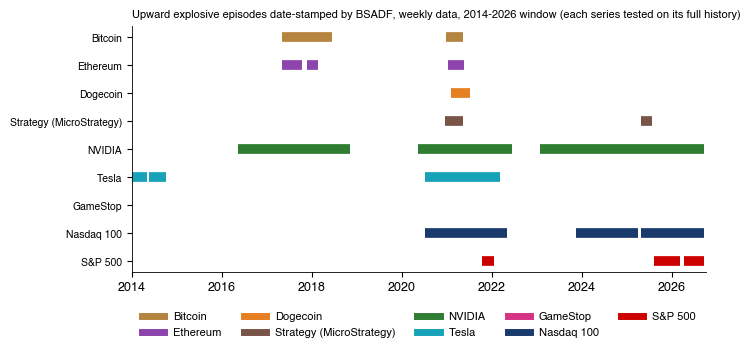

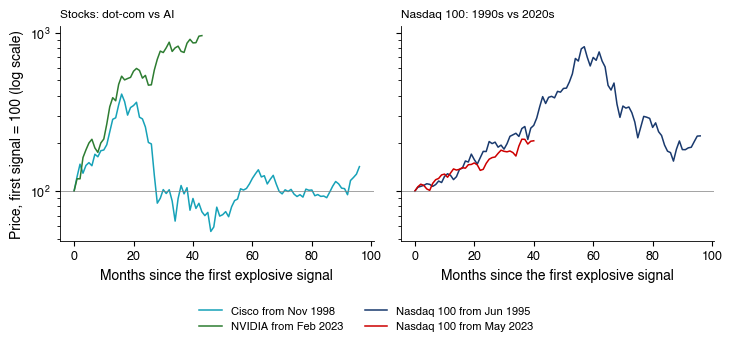

{'csco': {'start': '1998-11-30',
  'months': 96,
  'peak_mult': 4.102808147185645,
  'months_to_peak': 16,
  'last_mult': 1.4280582982280452},
 'nvda': {'start': '2023-02-28',
  'months': 43,
  'peak_mult': 9.60602629372564,
  'months_to_peak': 43,
  'last_mult': 9.60602629372564},
 'ndx95': {'start': '1995-06-30',
  'months': 96,
  'peak_mult': 8.173967622623271,
  'months_to_peak': 57,
  'last_mult': 2.233499804843596},
 'ndx23': {'start': '2023-05-31',
  'months': 40,
  'peak_mult': 2.128033436410648,
  'months_to_peak': 36,
  'last_mult': 2.0796957445855275}}

In [25]:
TIMELINE = ['btc', 'eth', 'doge', 'mstr', 'nvda', 'tsla', 'gme', 'ndx', 'sp500']


def fig_timeline():
    out = {}
    fig, ax = plt.subplots(figsize=(7.4, 3.2))
    cols = [Amber, Purple, Orange, Brown, Forest, Teal, Magenta, MainBlue, IDAred]
    for i, (k, c) in enumerate(zip(TIMELINE, cols)):
        y = np.log(price(k, 'W'))
        o = run_psy(y, R=1000)
        out[k] = summarise(o, y)
        for s, e, _ in o['ep']:
            e2 = e if e is not None else y.index[-1]
            if e2 < pd.Timestamp('2014-01-01') or _chg(y, s, e) <= 0:
                continue                                   # rising episodes only, 2014-2026
            ax.plot([max(s, pd.Timestamp('2014-01-01')), e2], [i, i], color=c, lw=7, solid_capstyle='butt')
        ax.plot([], [], color=c, lw=5, label=LABELS[k])
    ax.set_yticks(range(len(TIMELINE)))
    ax.set_yticklabels([LABELS[k] for k in TIMELINE], fontsize=7.5)
    ax.invert_yaxis()
    ax.set_xlim(pd.Timestamp('2014-01-01'), pd.Timestamp('2026-10-01'))
    ax.set_title('Upward explosive episodes date-stamped by BSADF, weekly data, 2014-2026 window (each series tested on its full history)',
                 fontsize=8, loc='left')
    legend_outside_bottom(ax, ncol=5, y=-0.12)
    save_fig('ch17_timeline')
    return out


def fig_ai_dotcom():
    """Cisco (dot-com) vs NVIDIA (AI) and Nasdaq 100 1995 vs 2023: price = 100 at the start of the explosive episode (monthly)."""
    res = {}
    for k in ['csco', 'nvda', 'ndx']:
        y = np.log(price(k, 'M'))
        res[k] = (y, run_psy(y))
    # start of the first dot-com episode (Cisco, Nasdaq 100) and of the current episode (NVIDIA, Nasdaq 100)
    def first_after(o, date):
        return next(s for s, e, n in o['ep'] if s >= pd.Timestamp(date))
    starts = {'csco': first_after(res['csco'][1], '1995-01-01'), 'nvda': first_after(res['nvda'][1], '2023-01-01'),
              'ndx95': first_after(res['ndx'][1], '1995-01-01'), 'ndx23': first_after(res['ndx'][1], '2023-01-01')}
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0), sharey=True)
    out = {}
    for ax, pairs in zip(axes, [[('csco', 'csco', 'Cisco from ', Teal), ('nvda', 'nvda', 'NVIDIA from ', Forest)],
                                [('ndx', 'ndx95', 'Nasdaq 100 from ', MainBlue), ('ndx', 'ndx23', 'Nasdaq 100 from ', IDAred)]]):
        for k, sk, lab, c in pairs:
            p = np.exp(res[k][0])
            s = starts[sk]
            w = p.loc[s:s + pd.DateOffset(months=96)]
            m = np.arange(len(w))
            ax.plot(m, 100 * w.values / w.iloc[0], color=c, lw=1.1, label=f'{lab}{s:%b %Y}')
            out[sk] = dict(start=d2s(s), months=int(len(w) - 1), peak_mult=float(w.max() / w.iloc[0]),
                           months_to_peak=int(np.argmax(w.values)), last_mult=float(w.iloc[-1] / w.iloc[0]))
        ax.set_yscale('log')
        ax.axhline(100, color=Gray, lw=0.5)
        ax.set_xlabel('Months since the first explosive signal')
    axes[0].set_ylabel('Price, first signal = 100 (log scale)')
    axes[0].set_title('Stocks: dot-com vs AI', fontsize=8.5, loc='left')
    axes[1].set_title('Nasdaq 100: 1990s vs 2020s', fontsize=8.5, loc='left')
    fig.tight_layout()
    fig_legend(fig, axes, ncol=2, y=0.0)
    save_fig('ch17_ai_dotcom')
    for k in ['csco', 'nvda', 'ndx']:
        out[f'psy_{k}'] = summarise(res[k][1], res[k][0])
    return out


tl = fig_timeline()
ai = fig_ai_dotcom()
{k: v for k, v in ai.items() if not k.startswith('psy_')}